# The DKW inequality: a confidence band for a whole CDF

[Open in Colab](https://colab.research.google.com/github/andreasmang/stan/blob/main/demos/dkw.ipynb) &nbsp;·&nbsp; nothing to install &nbsp;·&nbsp; **Runtime > Run all** takes a few seconds

The empirical CDF $\widehat F_n(x)$ is the fraction of the sample at or below $x$. At one fixed
$x$ it is a sample proportion, so the CLT gives a confidence interval for $F(x)$ at that $x$.
The Dvoretzky--Kiefer--Wolfowitz (DKW) inequality says much more: for every $\varepsilon>0$,

$$\mathbb{P}\Big(\sup_{x}\,\big|\widehat F_n(x) - F(x)\big| > \varepsilon\Big) \;\le\; 2e^{-2n\varepsilon^2},$$

whatever $F$ is. It bounds the **largest** gap between $\widehat F_n$ and $F$, over all $x$ at once.
Setting the right-hand side equal to $\alpha$ and solving for $\varepsilon$ gives

$$\varepsilon_n = \sqrt{\frac{\log(2/\alpha)}{2n}}, \qquad
L(x) = \max\{\widehat F_n(x) - \varepsilon_n,\, 0\}, \qquad
U(x) = \min\{\widehat F_n(x) + \varepsilon_n,\, 1\},$$

and then $\mathbb{P}\big(L(x)\le F(x)\le U(x) \text{ for all } x\big) \ge 1-\alpha$.

In [1]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(183)
n, alpha = 100, 0.05
eps = np.sqrt(np.log(2 / alpha) / (2 * n))       # = sqrt(log 40 / 200) for n = 100
print(f"n = {n}, alpha = {alpha}:  eps_n = {eps:.3f}")

def sup_gap(x):
    # sup_x |F_n(x) - x| for a Uniform(0,1) sample; the sup is attained at a data point
    x, m = np.sort(x), len(x)
    i = np.arange(1, m + 1)
    return max(np.max(i / m - x), np.max(x - (i - 1) / m))

n = 100, alpha = 0.05:  eps_n = 0.136


## 1. One sample, one band

Draw $n=100$ points from $\text{Uniform}(0,1)$, whose true CDF is the diagonal $F(x)=x$.
Plot the empirical CDF (blue steps), the DKW band around it (shaded), and the truth (black).

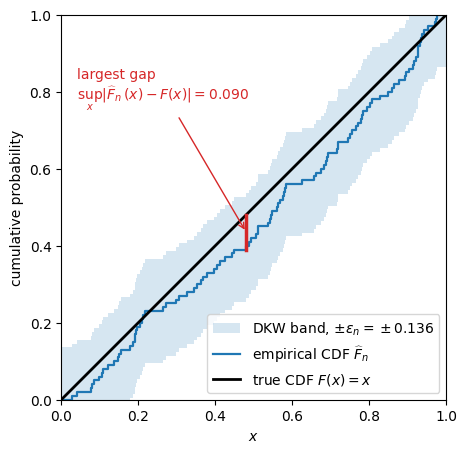

largest gap = 0.090   vs   eps_n = 0.136   ->   band covers F everywhere: True


In [2]:
x = np.sort(rng.uniform(0, 1, n))
xs = np.concatenate([[0], x, [1]])                 # step function on [0, 1]
Fn = np.concatenate([[0], np.arange(1, n + 1) / n, [1]])
L, U = np.clip(Fn - eps, 0, 1), np.clip(Fn + eps, 0, 1)

# the largest vertical gap between F_n and F, and where it happens
i = np.arange(1, n + 1)
above, below = i / n - x, x - (i - 1) / n          # gap just after / just before each x_(i)
k = int(np.argmax(np.maximum(above, below)))
xk = x[k]
y0, y1 = (xk, (k + 1) / n) if above[k] >= below[k] else (k / n, xk)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.fill_between(xs, L, U, step="post", color="C0", alpha=0.18, lw=0, label=f"DKW band, $\\pm\\varepsilon_n = \\pm{eps:.3f}$")
ax.step(xs, Fn, where="post", color="C0", lw=1.6, label="empirical CDF $\\widehat F_n$")
ax.plot([0, 1], [0, 1], "k", lw=2, label="true CDF $F(x)=x$")
ax.plot([xk, xk], [y0, y1], color="C3", lw=2.5)
ax.annotate(f"largest gap\n$\\sup_x|\\widehat F_n(x)-F(x)| = {abs(y1 - y0):.3f}$",
            xy=(xk, (y0 + y1) / 2), xytext=(0.04, 0.78),
            color="C3", arrowprops=dict(arrowstyle="->", color="C3"))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_xlabel("$x$"); ax.set_ylabel("cumulative probability"); ax.legend(loc="lower right")
plt.show()

print(f"largest gap = {sup_gap(x):.3f}   vs   eps_n = {eps:.3f}   ->   band covers F everywhere: {sup_gap(x) <= eps}")

The band surrounds the **entire** black line at once. Every vertical gap between the blue
steps and the diagonal is some distance $|\widehat F_n(x)-F(x)|$; the red segment marks the
largest of them. The band covers $F$ everywhere exactly when that largest gap is at most
$\varepsilon_n$, and DKW controls precisely that largest gap. That is what makes this a
*band* and not a stack of separate pointwise intervals.

## 2. In repeated samples

The claim is about the procedure, not this one picture: *in repeated samples, at least 95%
of these bands cover the whole true CDF.* Check it by drawing many samples.

fraction of 5000 bands covering all of F:  0.953   (DKW guarantees at least 0.95)


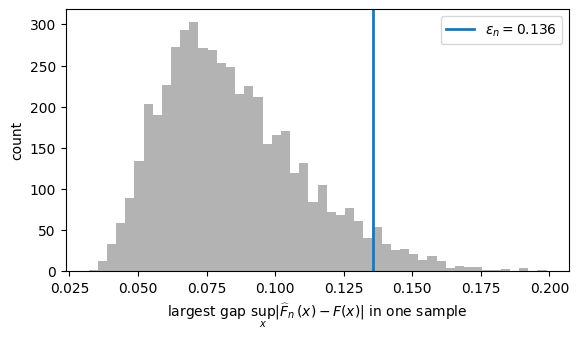

In [3]:
reps = 5000
gaps = np.array([sup_gap(rng.uniform(0, 1, n)) for _ in range(reps)])
print(f"fraction of {reps} bands covering all of F:  {np.mean(gaps <= eps):.3f}   (DKW guarantees at least {1 - alpha})")

plt.figure(figsize=(6.5, 3.4))
plt.hist(gaps, bins=50, color="0.7")
plt.axvline(eps, color="C0", lw=2, label=f"$\\varepsilon_n = {eps:.3f}$")
plt.xlabel("largest gap $\\sup_x|\\widehat F_n(x)-F(x)|$ in one sample"); plt.ylabel("count"); plt.legend()
plt.show()

Coverage comes out a little **above** 95%: DKW is an inequality, valid for every $F$ and
every $n$, so it is slightly conservative. The histogram shows why the band has to be as wide
as it is: the largest gap in a sample of 100 is typically around $0.08$, but it is not rare
for it to reach $0.12$ or more.

Nothing here used that $F$ is uniform. The same $\varepsilon_n$ works for any distribution,
because the largest gap has the same distribution whenever $F$ is continuous.

## 3. How the band shrinks

$\varepsilon_n$ falls like $1/\sqrt{n}$: four times the data halves the width.

In [4]:
for m in [25, 100, 400, 1600, 6400]:
    print(f"n = {m:5d}:  eps_n = {np.sqrt(np.log(2 / alpha) / (2 * m)):.3f}")

n =    25:  eps_n = 0.272
n =   100:  eps_n = 0.136
n =   400:  eps_n = 0.068
n =  1600:  eps_n = 0.034
n =  6400:  eps_n = 0.017


---

This notebook is part of [STAN](https://github.com/andreasmang/stan), the code repository
for MATH 166 (Statistics) at Tufts University. The DKW inequality is Theorem 7.5 in
Wasserman, *All of Statistics*.